Suppress all Warnings:

In [ ]:
import warnings
import sys
import logging

# Suppress all warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Suppress logging from libraries
logging.getLogger().setLevel(logging.ERROR)

# Suppress stderr output (optional, extreme)
class DevNull:
    def write(self, msg): pass
    def flush(self): pass

sys.stderr = DevNull()

Seeding:

In [ ]:
import random, numpy as np
import torch

# Set global seeds
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

**1. Loading of Datasets:**

In [ ]:

import pandas as pd

file_path = "reviews.csv"

# Load the dataset with all original columns
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Total rows: {len(df)}")
print(f"Columns loaded: {list(df.columns)}")

Dataset loaded successfully.
Total rows: 6446
Columns loaded: ['brand', 'review_id', 'score', 'at', 'content', 'reply_content', 'thumbs_up', 'review_created_version']


**2. Schema:**

In [ ]:
# ============================
# SCHEMA SNAPSHOT: df.info()
# ============================

print("Schema Overview:")
df.info()

Schema Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6446 entries, 0 to 6445
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   brand                   6446 non-null   object
 1   review_id               6446 non-null   object
 2   score                   6446 non-null   int64 
 3   at                      6446 non-null   object
 4   content                 6446 non-null   object
 5   reply_content           435 non-null    object
 6   thumbs_up               6446 non-null   int64 
 7   review_created_version  5766 non-null   object
dtypes: int64(2), object(6)
memory usage: 403.0+ KB


**3. Data Audit:**

In [ ]:
# ============================
# Overall Data Audit
# ============================

col = 'reply_content'

print(f"\nAudit: '{col}' column")

# Count missing values
missing_count = df[col].isna().sum()
missing_pct = (missing_count / len(df)) * 100

print(f"Missing values: {missing_count} ({missing_pct:.2f}%)")

# Unique non-null values
unique_non_null = df[col].nunique(dropna=True)
print(f"Unique non-null values: {unique_non_null}")

# Most common non-null reply (if any)
if unique_non_null > 0:
    most_common = df[col].dropna().mode()[0]
    most_common_count = df[col].dropna().value_counts().iloc[0]
    print(f"Most common reply: \"{most_common}\" ({most_common_count} occurrences)")
else:
    print("Most common reply: None (all values are NaN)")

# Show a few examples of NaN rows for clarity
print("\nSample rows with NaN reply_content:")
display(df[df[col].isna()].head())


Audit: 'reply_content' column
Missing values: 6011 (93.25%)
Unique non-null values: 427
Most common reply: "Thanks for your review. Latest version was mistakenly our internal testing build. The visible activity data is used exclusively for internal debugging purposes. No data was transmitted to any external or 3rd party system and there was no data breach or security issue whatsoever.
Please update to the latest version. Thanks for your understanding." (6 occurrences)

Sample rows with NaN reply_content:


,brand,review_id,score,at,content,reply_content,thumbs_up,review_created_version
0,nike,4e0beb34-9bc6-4dfb-9f73-8cf3750571fa,5,10/10/2025 5:12,great!,NaN,0,25.46.1
1,nike,a944523b-a77a-4709-a77c-bd6c7e722be1,5,10/10/2025 3:59,excellent,NaN,0,25.45.1
2,nike,b6b37895-02bc-4986-9316-0a830b0ead7d,4,10/10/2025 3:36,"If I didn’t have to keep logging in, it would ...",NaN,0,25.46.1
3,nike,1b6d59fa-7c85-4f4a-8232-5710bd15c80d,2,10/10/2025 2:53,not user friendly,NaN,0,NaN
4,nike,85e31a6e-4695-4aae-8af6-44dde7719610,5,10/10/2025 2:41,Amazing,NaN,0,25.46.1


**3a. Audit of Missing Values and Sparse Columns**

In [ ]:
print("Data Audit:")

for col in df.columns:
    print(f"\nColumn: {col}")
    missing_count = df[col].isna().sum()
    missing_pct = (missing_count / len(df)) * 100
    print(f"Missing values: {missing_count} ({missing_pct:.2f}%)")

    if pd.api.types.is_numeric_dtype(df[col]):
        print(" - Numeric Stats:")
        print(f"   * Mean: {df[col].mean():.2f}")
        print(f"   * Median: {df[col].median():.2f}")
        print(f"   * Min: {df[col].min():.2f}")
        print(f"   * Max: {df[col].max():.2f}")
        print(f"   * Std Dev: {df[col].std():.2f}")
    else:
        unique_count = df[col].nunique(dropna=True)
        most_common = df[col].mode()[0] if not df[col].mode().empty else None
        most_common_count = df[col].value_counts().iloc[0] if not df[col].value_counts().empty else 0
        print(f" - Unique values: {unique_count}")
        print(f" - Most common: {most_common} ({most_common_count} occurrences)")

# Validate thumbs_up distribution
zero_thumbs_up_count = (df['thumbs_up'] == 0).sum()
zero_thumbs_up_pct = (zero_thumbs_up_count / len(df)) * 100
print(f"\nPercentage of reviews with 0 thumbs_up: {zero_thumbs_up_pct:.2f}%")

Data Audit:

Column: brand
Missing values: 0 (0.00%)
 - Unique values: 4
 - Most common: adidas (2000 occurrences)

Column: review_id
Missing values: 0 (0.00%)
 - Unique values: 6446
 - Most common: 0003f040-42a9-48a9-b5a8-d6b69b90f241 (1 occurrences)

Column: score
Missing values: 0 (0.00%)
 - Numeric Stats:
   * Mean: 4.00
   * Median: 5.00
   * Min: 1.00
   * Max: 5.00
   * Std Dev: 1.59

Column: at
Missing values: 0 (0.00%)
 - Unique values: 6397
 - Most common: 1/10/2025 22:20 (2 occurrences)

Column: content
Missing values: 0 (0.00%)
 - Unique values: 5180
 - Most common: good (224 occurrences)

Column: reply_content
Missing values: 6011 (93.25%)
 - Unique values: 427
 - Most common: Thanks for your review. Latest version was mistakenly our internal testing build. The visible activity data is used exclusively for internal debugging purposes. No data was transmitted to any external or 3rd party system and there was no data breach or security issue whatsoever.
Please update to the 

**4. Importing Library and Relevant Attributes Assessment:**

In [ ]:
import pandas as pd

# Load only relevant columns
df = pd.read_csv(
    "reviews.csv",
    usecols=["review_id", "brand", "score", "at", "content",
    "thumbs_up"])

print(df.head())
print(df.info())

  brand                             review_id  score               at  \
0  nike  4e0beb34-9bc6-4dfb-9f73-8cf3750571fa      5  10/10/2025 5:12   
1  nike  a944523b-a77a-4709-a77c-bd6c7e722be1      5  10/10/2025 3:59   
2  nike  b6b37895-02bc-4986-9316-0a830b0ead7d      4  10/10/2025 3:36   
3  nike  1b6d59fa-7c85-4f4a-8232-5710bd15c80d      2  10/10/2025 2:53   
4  nike  85e31a6e-4695-4aae-8af6-44dde7719610      5  10/10/2025 2:41   

                                             content  thumbs_up  
0                                             great!          0  
1                                          excellent          0  
2  If I didn’t have to keep logging in, it would ...          0  
3                                  not user friendly          0  
4                                            Amazing          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6446 entries, 0 to 6445
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     ----

**5. Duplicate and Missing Content Audit:**

In [ ]:
# Duplicates across all columns
print("Total duplicate rows:", df.duplicated().sum())

# Missing brand
print ("Missing brand:", df["brand"].isna().sum())

# Missing content
print("Missing content:", df["content"].isna().sum())

# Score validity (should be empty)
invalid_scores = df[~df["score"].between(1, 5)]
print("Invalid scores:\n", invalid_scores)



Total duplicate rows: 0
Missing brand: 0
Missing content: 0
Invalid scores:
 Empty DataFrame
Columns: [brand, review_id, score, at, content, thumbs_up]
Index: []


**6. Data Cleaning & Transformation:**

In [ ]:
# Brand as category
df["brand"] = df["brand"].astype("category")

# Review length
df["review_length"] = df["content"].str.len()
print("Average review length:", df["review_length"].mean())
df["review_length"].describe()



Average review length: 61.685541421036305


,review_length
count,6446.000000
mean,61.685541
std,91.084339
min,1.000000
25%,10.000000
50%,27.000000
75%,70.000000
max,500.000000


missing timestamps does not affect text modelling and will be retained for completeness

6a. EDA:

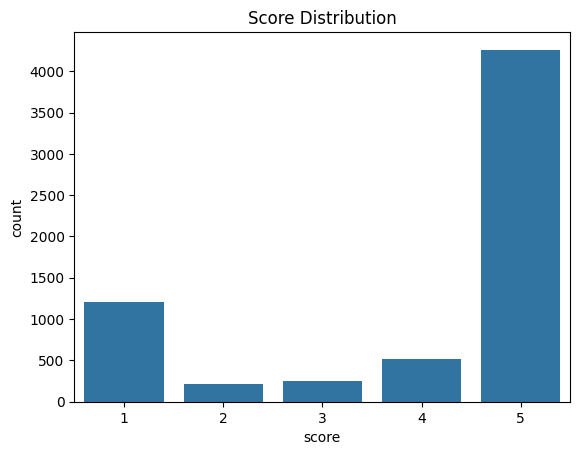

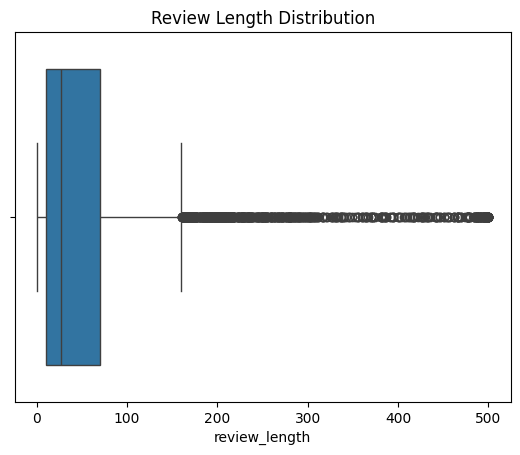

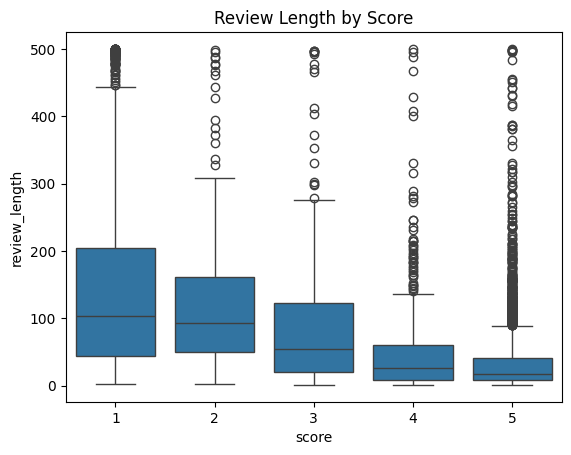

Correlation (score vs thumbs_up): -0.0531579549250386


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Score distribution
#sns.countplot(x=df["score"])#old
sns.countplot(x="score",data=df)
plt.title("Score Distribution")
plt.show()

# Review length distribution
sns.boxplot(x=df["review_length"])
plt.title("Review Length Distribution")
plt.show()

# Review length by score
sns.boxplot(x=df["score"], y=df["review_length"])
plt.title("Review Length by Score")
plt.show()

# Correlation between score and thumbs_up
corr = df["score"].corr(df["thumbs_up"])
print("Correlation (score vs thumbs_up):", corr)

6b. Exploratory Plot:





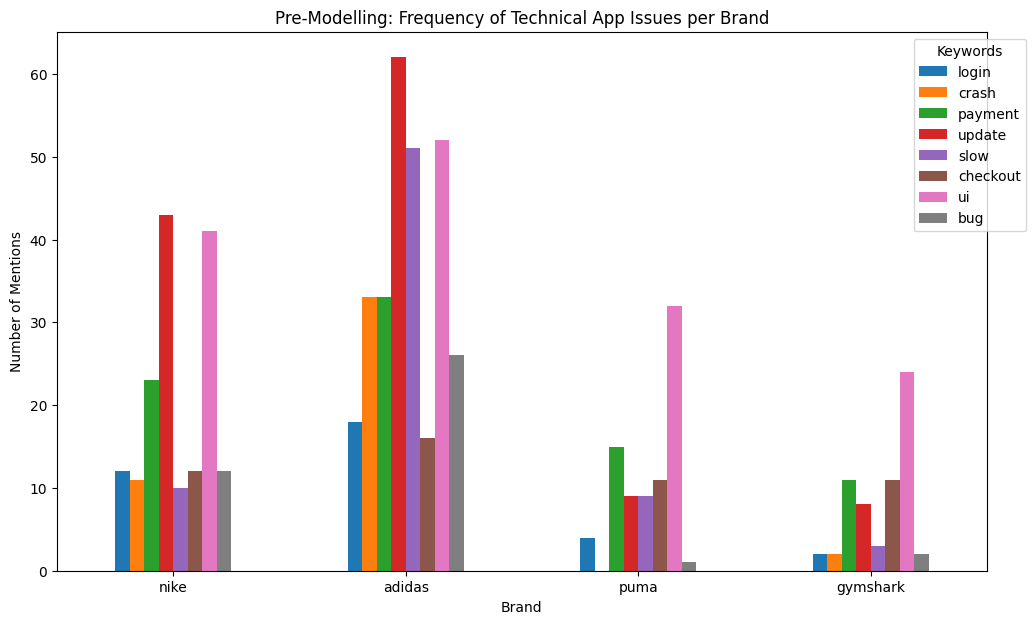

In [ ]:
# Defining app-specific technical keywords to check for 'App vs Brand' distinction
app_keywords = ['login', 'crash', 'payment', 'update', 'slow', 'checkout', 'ui', 'bug']

keyword_counts = []
for brand in df['brand'].unique():
    brand_df = df[df['brand'] == brand]
    # Count occurrences of these technical terms per brand
    counts = {kw: brand_df['content'].str.contains(kw, case=False).sum() for kw in app_keywords}
    counts['brand'] = brand
    keyword_counts.append(counts)

keyword_df = pd.DataFrame(keyword_counts).set_index('brand')

# Visualize the distribution of technical issues across the 4 brands
keyword_df.plot(kind='bar', figsize=(12, 7))
plt.title('Pre-Modelling: Frequency of Technical App Issues per Brand')
plt.ylabel('Number of Mentions')
plt.xlabel('Brand')
plt.xticks(rotation=0)
plt.legend(title='Keywords', bbox_to_anchor=(1.05, 1))
plt.show()

6c. Text Pre-processing:

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation & numbers
    tokens = [lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["content"].apply(preprocess)

6d. N-Gram Extraction & Brand-wise Comparisons:

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_ngrams = CountVectorizer(ngram_range=(2, 3), max_features=50)
X_ngrams = vectorizer_ngrams.fit_transform(df["clean_text"])

ngrams = vectorizer_ngrams.get_feature_names_out()
counts = X_ngrams.sum(axis=0).A1

ngram_freq = sorted(zip(ngrams, counts), key=lambda x: x[1], reverse=True)
print("Top 20 n-grams:")
for ngram, freq in ngram_freq[:20]:
    print(f"{ngram}: {freq}")

Top 20 n-grams:
easy use: 192
great app: 160
love app: 120
customer service: 117
good app: 105
easy navigate: 84
love puma: 74
app easy: 72
best app: 59
love nike: 55
nice app: 53
nike app: 53
great deal: 51
love adidas: 49
customer care: 48
good quality: 46
user friendly: 39
worst app: 38
app doesnt: 37
app great: 37


6e. Post-Processing EDA:Bigrams Analysis:




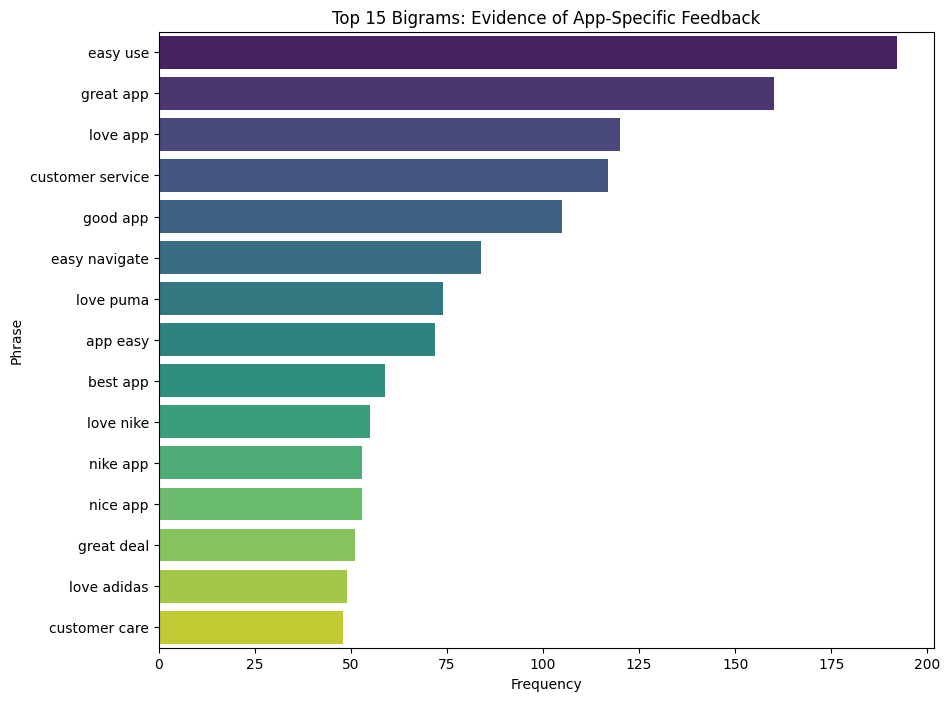

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_bigrams(corpus, top_k=15):
    # n-gram_range=(2, 2) focuses on word pairs to preserve semantic meaning
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

    top_df = pd.DataFrame(words_freq[:top_k], columns=['Phrase', 'Frequency'])

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Frequency', y='Phrase', data=top_df, palette='viridis')
    plt.title('Top 15 Bigrams: Evidence of App-Specific Feedback')
    plt.show()

plot_top_bigrams(df['clean_text'])

Stopwords, punctuation removed and Lemmatisation applied
Latter is chosen over stemmer to preserve the semantics of
the words/phrases.

**7. Prepare Data for Topic Modelling:**

7a. Installing gensim:

In [ ]:
!pip install gensim

7b. Vectorisation (BOW):

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Vectorise cleaned text
vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=5,
    stop_words='english')

bow_matrix = vectorizer.fit_transform(df["clean_text"])
id2word = vectorizer.get_feature_names_out()

7c. Prepare corpus for Gensim LDA:

In [ ]:
from gensim.corpora import Dictionary

texts = [t.split() for t in df["clean_text"]]
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(t) for t in texts]

**8. LDA Topic Modelling:**

8a. LDA Hyperparameter Tuning:

In [ ]:
from gensim.models.ldamodel import LdaModel

topic_nums = [5, 10, 15]
lda_models = {}

for k in topic_nums:
    lda_models[k] = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=20,
        random_state=42)

8b. Coherence Evaluation:

In [ ]:
from gensim.models import CoherenceModel

coherence_scores = {}

for k, model in lda_models.items():
    cm = CoherenceModel(
        model=model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v')
    coherence_scores[k] = cm.get_coherence()
    print(f"Coherence for {k} topics: {coherence_scores[k]:.4f}")

Coherence for 5 topics: 0.5037
Coherence for 10 topics: 0.4537
Coherence for 15 topics: 0.4919


In [ ]:
print("\nExtracted Topics for 5 vs 10:")

print("\n--- 5 Topics ---")
for idx, topic in lda_models[5].show_topics(num_topics=5, num_words=10, formatted=False):
    words = [w for w, p in topic]
    print(f"Topic {idx}: {', '.join(words)}")

print("\n--- 10 Topics ---")
for idx, topic in lda_models[10].show_topics(num_topics=10, num_words=10, formatted=False):
    words = [w for w, p in topic]
    print(f"Topic {idx}: {', '.join(words)}")


Extracted Topics for 5 vs 10:

--- 5 Topics ---
Topic 0: nice, item, cant, wait, address, available, add, app, fantastic, cart
Topic 1: great, app, easy, love, quality, use, puma, product, service, shoe
Topic 2: order, customer, dont, time, day, get, return, service, shoe, even
Topic 3: love, best, app, clothes, excellent, gym, awesome, gymshark, clothing, quality
Topic 4: good, app, work, doesnt, cant, super, time, working, payment, error

--- 10 Topics ---
Topic 0: size, poor, address, delivery, stock, u, fantastic, change, min, comfy
Topic 1: love, puma, shoe, adidas, app, nike, brand, customer, service, company
Topic 2: time, checkout, everything, could, see, way, process, long, use, purchase
Topic 3: quality, gym, product, clothes, best, clothing, fit, gymshark, price, like
Topic 4: good, app, friendly, super, user, experience, service, product, lot, stuff
Topic 5: best, excellent, app, working, easier, payment, sign, ever, service, product
Topic 6: great, easy, app, use, love, a

8c. Perplexity Evaluation:

In [ ]:
perplexity_scores = {}

for k, model in lda_models.items():
    perplexity_scores[k] = model.log_perplexity(corpus)
    print(f"Perplexity for {k} topics: {perplexity_scores[k]}")

Perplexity for 5 topics: -7.165632472641786
Perplexity for 10 topics: -7.322504265715555
Perplexity for 15 topics: -8.920832461299216


8d. Select best Topic Number (based on Coherence):

In [ ]:
best_k = max(coherence_scores, key=coherence_scores.get)
best_lda = lda_models[best_k]

print(f"Selected number of topics: {best_k}")

Selected number of topics: 5


8e. Display Top Words for Each Topic:

In [ ]:
# Collect topics into a structured list
topic_rows = []
for idx, topic in best_lda.show_topics(num_topics=best_k, num_words=10, formatted=False):
    words = [w for w, p in topic]
    topic_rows.append({
        "Topic ID": idx,
        "Top Words": ", ".join(words)
    })

# Convert to DataFrame for neat display
topics_df = pd.DataFrame(topic_rows)
print(topics_df)

   Topic ID                                          Top Words
0         0  nice, item, cant, wait, address, available, ad...
1         1  great, app, easy, love, quality, use, puma, pr...
2         2  order, customer, dont, time, day, get, return,...
3         3  love, best, app, clothes, excellent, gym, awes...
4         4  good, app, work, doesnt, cant, super, time, wo...


8f. pyLDAvis Visualisation:

In [ ]:
!pip install pyLDAvis

import pyLDAvis
import pyLDAvis.gensim

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(best_lda, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.134975  0.089006       1        1  28.923553
1     -0.192239  0.060916       2        1  25.878274
4      0.129425  0.161345       3        1  21.055410
0      0.125610 -0.255874       4        1  12.245151
3     -0.197771 -0.055393       5        1  11.897611, topic_info=           Term         Freq        Total Category  logprob  loglift
91         good   918.000000   918.000000  Default  30.0000  30.0000
0         great   800.000000   800.000000  Default  29.0000  29.0000
64         love   606.000000   606.000000  Default  28.0000  28.0000
58         easy   500.000000   500.000000  Default  27.0000  27.0000
60          app  1645.000000  1645.000000  Default  26.0000  26.0000
..          ...          ...          ...      ...      ...      ...
482         see    23.678834    84.638142   Topic5  -5.3573   0.8550
135     product    34.335889   442.460326   Topic5  -4.9857  -0.4273
224        work    26.412119   182.062087   Topic5  -5.2480   0.1983
398       style    20.616791    62.438312   Topic5  -5.4958   1.0208
95   everything    20.208204    83.165318   Topic5  -5.5158   0.7141

[298 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
3129      4  0.964990         aap
358       1  0.379039  absolutely
358       5  0.602003  absolutely
297       1  0.448997      access
297       4  0.523829      access
...     ...       ...         ...
6         1  0.707065       would
6         2  0.159660       would
6         4  0.125447       would
333       5  0.957361         wow
257       1  0.972064         yet

[412 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 2, 5, 1, 4])

8g. Assign Dominant Topic to Each Review:

In [ ]:
doc_topics = [best_lda.get_document_topics(bow) for bow in corpus]

dominant_topics = []
for doc in doc_topics:
    if doc:
        dominant_topics.append(max(doc, key=lambda x: x[1])[0])
    else:
        dominant_topics.append(None)

df["dominant_topic"] = dominant_topics

8h. Brand-Wise Topic Distribution:

In [ ]:
brand_topic_counts = df.groupby(["brand", "dominant_topic"]).size().unstack(fill_value=0)
brand_topic_counts


dominant_topic,0,1,2,3,4
brand,,,,,
adidas,268,516,428,220,568
gymshark,54,155,68,105,64
nike,195,675,246,375,509
puma,248,705,222,395,430


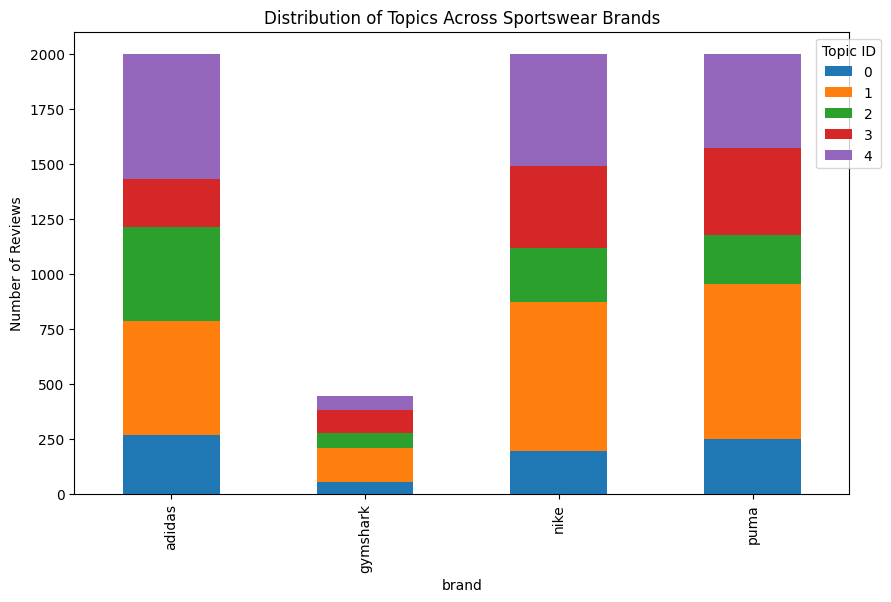

In [ ]:
brand_topic_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Distribution of Topics Across Sportswear Brands")
plt.ylabel("Number of Reviews")
plt.legend(title="Topic ID", bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
#saving LDA modelling

# Saving each LDA model in the dictionary
for k, model in lda_models.items():
    model.save(f"lda_model_{k}_topics")

**9. BERTopic Modelling:**

9a. Import and install BERTopic Components:

In [ ]:
!pip install bertopic sentence-transformers umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.3 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# --- Imports ---
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sentence_transformers import SentenceTransformer

# --- Define embedding model ---
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")  # lightweight, fast

# --- Initialize results dictionary ---
brand_results = {}

# --- Process each brand ---
for b in ["nike", "adidas", "puma", "gymshark"]:
    df_b = df[df["brand"] == b]

    # LDA
    texts_b = [t.split() for t in df_b["clean_text"]]
    dictionary_b = Dictionary(texts_b)
    corpus_b = [dictionary_b.doc2bow(t) for t in texts_b]
    lda_b = LdaModel(corpus=corpus_b, id2word=dictionary_b,
                     num_topics=5, passes=20, random_state=42)
    lda_topics_b = lda_b.show_topics(num_topics=5, num_words=10, formatted=False)

    # BERTopic (using defaults for ctfidf, umap, hdbscan unless you tuned them earlier)
    docs_b = df_b["clean_text"].tolist()
    vectorizer_model_b = CountVectorizer(stop_words="english", min_df=1, max_df=0.95)

    topic_model_b = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model_b,
        verbose=True)

    topics_b, probs_b = topic_model_b.fit_transform(docs_b)
    topic_info_b = topic_model_b.get_topic_info()

    brand_results[b] = {
        "lda_model": lda_b,
        "lda_topics": lda_topics_b,
        "bert_model": topic_model_b,
        "bert_topics": topic_info_b,
        "bert_topic_assignments": topics_b }

print("Brands processed:", brand_results.keys())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Brands processed: dict_keys(['nike', 'adidas', 'puma', 'gymshark'])


In [ ]:
from bertopic.vectorizers import ClassTfidfTransformer

ctfidf_model = ClassTfidfTransformer()

topic_model_b = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model_b,
    ctfidf_model=ctfidf_model,
    verbose=True)

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sentence_transformers import SentenceTransformer

# Define embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

brand_results = {}

for b in ["nike", "adidas", "puma", "gymshark"]:
    df_b = df[df["brand"] == b]

    # LDA
    texts_b = [t.split() for t in df_b["clean_text"]]
    dictionary_b = Dictionary(texts_b)
    corpus_b = [dictionary_b.doc2bow(t) for t in texts_b]
    lda_b = LdaModel(corpus=corpus_b, id2word=dictionary_b,
                     num_topics=5, passes=20, random_state=42)
    lda_topics_b = lda_b.show_topics(num_topics=5, num_words=10, formatted=False)

    # BERTopic (defaults for ctfidf, umap, hdbscan)
    docs_b = df_b["clean_text"].tolist()
    vectorizer_model_b = CountVectorizer(stop_words="english", min_df=1, max_df=0.95)

    topic_model_b = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model_b,
        verbose=True)

    topics_b, probs_b = topic_model_b.fit_transform(docs_b)
    topic_info_b = topic_model_b.get_topic_info()

    brand_results[b] = {
        "lda_model": lda_b,
        "lda_topics": lda_topics_b,
        "bert_model": topic_model_b,
        "bert_topics": topic_info_b,
        "bert_topic_assignments": topics_b}

print("Brands processed:", brand_results.keys())


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Brands processed: dict_keys(['nike', 'adidas', 'puma', 'gymshark'])


In [ ]:
# Standardize BERTopic output headers
brand_results[b]["bert_topics"].rename(columns={
    "Topic": "Topic ID",
    "Name": "Topic Label",
    "Representation": "Top Keywords",
    "Count": "Document Count"}, inplace=True)

In [ ]:
from bertopic import BERTopic
topic_model = BERTopic()

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer

9b. BERTopic Topic Modelling - Base Run:

In [ ]:
docs = df["clean_text"].tolist()

In [ ]:
# Rebuild Base Model (Round 0)
embedding_model_base = SentenceTransformer("all-MiniLM-L6-v2")

topic_model_base = BERTopic(
    embedding_model=embedding_model_base,
    verbose=True)

topics_base, probs_base = topic_model_base.fit_transform(docs)
topic_info_base = topic_model_base.get_topic_info()
topic_info_base

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/202 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1320,-1_order_shoe_time_item,"[order, shoe, time, item, work, even, cant, cu...",[getting refund even month initiating return m...
1,0,120,0_ordered_return_adidas_refund,"[ordered, return, adidas, refund, shoe, custom...",[guy please buy anything online scamsters puma...
2,1,101,1_shopping_discount_deal_app,"[shopping, discount, deal, app, shoping, great...","[easy use shopping app, best app shopping easy..."
3,2,98,2_address_country_india_language,"[address, country, india, language, uk, locati...","[cant change location u uk, app showing addres..."
4,3,94,3_slow_loading_load_lag,"[slow, loading, load, lag, laggy, take, foreve...","[app slow load slow, slow loading, slow loadin..."
...,...,...,...,...,...
150,149,11,149_collection_grp_vgood_age,"[collection, grp, vgood, age, nice, every, goo...","[good collection, nice collection, nice collec..."
151,150,11,150_aap_soiyak_acha_batman,"[aap, soiyak, acha, batman, verry, nice, bad, ...","[good aap, good aap, good aap]"
152,151,10,151_fixed_disruption_performing_programmed,"[fixed, disruption, performing, programmed, se...","[app perfectly programmed disruption, think ap..."
153,152,10,152_navigate_navigation_navigategreat_recommends,"[navigate, navigation, navigategreat, recommen...",[convenient easy navigategreat accessing new t...


In [ ]:
topic_model_base.save("bertopic_base_model")

9c. Build Custom BERTopic Pipeline:

In [ ]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

umap_model = UMAP(
    n_neighbors=15,


    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42)

hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True)

vectorizer_model = CountVectorizer(
    ngram_range=(1, 3),
    stop_words="english")

ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True,
    bm25_weighting=True)

topic_model_base = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    verbose=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

9d. Fit BERTopic:

In [ ]:
topics_base, probs_base = topic_model_base.fit_transform(docs)

Batches:   0%|          | 0/202 [00:00<?, ?it/s]

9e. Topic Summary Table:

In [ ]:
topic_info = topic_model_base.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1362,-1_review_ordered_delivered_received,"[review, ordered, delivered, received, email, ...",[one worst frustrating apps ive used glitchy b...
1,0,246,0_love shoe_shoe great_jordan_sneaker,"[love shoe, shoe great, jordan, sneaker, nice ...",[need product review online buyer eg future pl...
2,1,124,1_shopping app_app great deal_app shopping_deal,"[shopping app, app great deal, app shopping, d...",[love gymshark app think sale code much better...
3,2,111,2_app easy use_interface_app easy_app smooth,"[app easy use, interface, app easy, app smooth...",[app work remarkably well greatful downloaded ...
4,3,105,3_login_log_sign_password,"[login, log, sign, password, account, log acco...",[last year issue woth app trying log account w...
...,...,...,...,...,...
117,116,17,116_experience great experience_experience nic...,"[experience great experience, experience nice,...","[nice experience, nice experience, great exper..."
118,117,17,117_bag_shopping bag_bag trying buy_open bag,"[bag, shopping bag, bag trying buy, open bag, ...",[keep saying there error opening shopping bag ...
119,118,16,118_app great great_great great app_app app gr...,"[app great great, great great app, app app gre...","[great app opinion, great app great kick, app ..."
120,119,16,119_cool cool_cool cool cool_cool_nay cool,"[cool cool, cool cool cool, cool, nay cool, co...","[cool, cool, cool cat]"


9f. Outlier Analysis (Base Run) :

In [ ]:
topic_info[topic_info["Topic"] == -1]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1362,-1_review_ordered_delivered_received,"[review, ordered, delivered, received, email, ...",[one worst frustrating apps ive used glitchy b...


9g. BERTopic Topic Modelling - Tuned Run:

In [ ]:
# Tuning Round 1 — UMAP + HDBSCAN
umap_model_tuned = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42)

hdbscan_model_tuned = HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True)

# Build tuned BERTopic model
topic_model_tuned = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model_tuned,
    hdbscan_model=hdbscan_model_tuned,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    verbose=True)

# Fit tuned model
topics_tuned, probs_tuned = topic_model_tuned.fit_transform(docs)

# Get tuned topic info
topic_info_tuned = topic_model_tuned.get_topic_info()
topic_info_tuned

Batches:   0%|          | 0/202 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,840,-1_bag_compatible_enable_superb,"[bag, compatible, enable, superb, awesome app,...",[onyx v midnight drop opened eye bad company r...
1,0,415,0_refund_return_care_customer care,"[refund, return, care, customer care, received...",[rating title extremely poor quality worst ret...
2,1,255,1_love shoe_shoe great_jordan_sneaker,"[love shoe, shoe great, jordan, sneaker, size,...",[need product review online buyer eg future pl...
3,2,134,2_open_update_crashing_app open,"[open, update, crashing, app open, open app, a...",[endless loop message saying new version app a...
4,3,132,3_shipping_fast delivery_fast_easy order,"[shipping, fast delivery, fast, easy order, de...",[easy see account information shop apply avail...
...,...,...,...,...,...
83,82,30,82_best best best_best best_vgood best best_vgood,"[best best best, best best, vgood best best, v...","[best, best, vgood]"
84,83,30,83_great selection_selection great selection_s...,"[great selection, selection great selection, s...","[great selection easy purchase, great selectio..."
85,84,30,84_looking great_word_night_exactly looking,"[looking great, word, night, exactly looking, ...","[actually dis idea said see done think, hope i..."
86,85,30,85_excellent excellent excellent_excellent exc...,"[excellent excellent excellent, excellent exce...","[excellent, excellent, excellent]"


In [ ]:
topic_model_round1 = topic_model_tuned
topic_model_round1.save("bertopic_round1_model")
topic_info_round1 = topic_model_round1.get_topic_info()

9h. Outlier Analysis:

In [ ]:
topic_info_tuned[topic_info_tuned["Topic"] == -1]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,840,-1_bag_compatible_enable_superb,"[bag, compatible, enable, superb, awesome app,...",[onyx v midnight drop opened eye bad company r...


In [ ]:
#Saving Round 1
topic_model_round1.save("bertopic_round1_model")



9i Tuning Round 2:

In [ ]:
topic_info_tuned.sort_values("Count", ascending=False).head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,840,-1_bag_compatible_enable_superb,"[bag, compatible, enable, superb, awesome app,...",[onyx v midnight drop opened eye bad company r...
1,0,415,0_refund_return_care_customer care,"[refund, return, care, customer care, received...",[rating title extremely poor quality worst ret...
2,1,255,1_love shoe_shoe great_jordan_sneaker,"[love shoe, shoe great, jordan, sneaker, size,...",[need product review online buyer eg future pl...
3,2,134,2_open_update_crashing_app open,"[open, update, crashing, app open, open app, a...",[endless loop message saying new version app a...
4,3,132,3_shipping_fast delivery_fast_easy order,"[shipping, fast delivery, fast, easy order, de...",[easy see account information shop apply avail...
5,4,126,4_shopping app_deal_app great deal_app shopping,"[shopping app, deal, app great deal, app shopp...",[good apploves order moreits item quickly post...
6,5,103,5_log_login_sign_password,"[log, login, sign, password, account, log acco...",[last year issue woth app trying log account w...
7,6,103,6_love adidas_adidas love_adidas love adidas_a...,"[love adidas, adidas love, adidas love adidas,...",[rocking adidas back breakdancing pop locking ...
8,7,101,7_slow_loading_load_slow app,"[slow, loading, load, slow app, lag, laggy, ap...",[app function well slow searching specific ite...
9,8,99,8_price_price high_great price_price great,"[price, price high, great price, price great, ...",[awesome product awesome price easy shopping o...


In [ ]:
# Use MiniLM again — faster, more stable
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Restore stable vectorizer
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    min_df=20,
    stop_words="english")

# Rebuild model with tuned UMAP + HDBSCAN
topic_model_tuned = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model_tuned,
    hdbscan_model=hdbscan_model_tuned,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    verbose=True)

# Refit model
topics_tuned, probs_tuned = topic_model_tuned.fit_transform(docs)

# Get topic info
topic_info_tuned = topic_model_tuned.get_topic_info()
topic_info_tuned

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/202 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,840,-1_stuff_used_thank_thats,"[stuff, used, thank, thats, look, year, going,...",[clothing great customer service since end mar...
1,0,415,0_know_place_going_bad,"[know, place, going, bad, company, thats, avai...",[order product money got debited received razo...
2,1,255,1_site_look_style_thats,"[site, look, style, thats, favorite, place, si...","[great price good work shoe, love price good s..."
3,2,134,2_apps_know_going_available,"[apps, know, going, available, app app, used, ...","[unable open app, app working, app opening]"
4,3,132,3_fast_lot_going_site,"[fast, lot, going, site, place, know, super, w...","[good app together shipping little expensive, ..."
...,...,...,...,...,...
83,82,30,82____,"[, , , , , , , , , ]","[best, best, best]"
84,83,30,83_style_lot_favorite_option,"[style, lot, favorite, option, purchase, amazi...","[great selection, great option, great selectio..."
85,84,30,84_going_look_need_available,"[going, look, need, available, want, stuff, lo...","[great geat, great hard find, fifteen minute l..."
86,85,30,85____,"[, , , , , , , , , ]","[excellent, excellent, excellent]"


In [ ]:
topic_model_round2 = topic_model_tuned

In [ ]:
#Saving Round 2 Tuning
topic_model_round2.save("bertopic_round2_model")

In [ ]:
topic_info_tuned[topic_info_tuned["Topic"] == -1]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,840,-1_stuff_used_thank_thats,"[stuff, used, thank, thats, look, year, going,...",[clothing great customer service since end mar...


9j. Intertopic Distance Map:

In [ ]:
topic_model_round1.visualize_topics()

9k. Hierarchical Topic Tree:

In [ ]:
topic_model_round1.visualize_hierarchy()

9l. Topic Size Distribution:

In [ ]:
topic_model_round1.visualize_barchart()

9m. Representative Documents

In [ ]:
topic_model_round1.get_representative_docs()

{-1: ['onyx v midnight drop opened eye bad company really aimed loyalty member max tier loyalty member one first queue buy right went checkout kicked website brought back app homepage loyal customer experience like joke ask customer support help get copy paste message save money time shop youngla',
  'better shopping online could use improvement cant sort wishlist based item type price low highhigh low back viewing something list remove sorting option reloads wishlist completely delay touch screen scroll item description responds item arent visible category product shortcut add item bag animated never stop pulsing',
  'didnt buy anything price rich blood uninstalled literally come back leave rating seriously best app ive ever used reason android like devs really went im blown away quality fluidity polish useful feature baked like wow truly impressive couldnt blown away im bot literally used ua reebok adidas nike apps nowhere close quality'],
 0: ['rating title extremely poor quality wo

9n. Brand-Level Modelling:

In [ ]:
# BRAND-LEVEL MODELLING
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel

brands = df["brand"].unique()
brand_results = {}

for b in brands:
    print(f"\nProcessing brand: {b}")
    df_b = df[df["brand"] == b]

    # ----- LDA for this brand -----
    texts_b = [t.split() for t in df_b["clean_text"]]
    dictionary_b = Dictionary(texts_b)
    corpus_b = [dictionary_b.doc2bow(t) for t in texts_b]

    lda_b = LdaModel(
        corpus=corpus_b,
        id2word=dictionary_b,
        num_topics=5,
        passes=20,
        random_state=42)

    lda_topics_b = lda_b.show_topics(num_topics=5, num_words=10, formatted=False)

    # ----- BERTopic for this brand -----
    docs_b = df_b["clean_text"].tolist()
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model_b = CountVectorizer(
    stop_words="english",
    min_df=1,
    max_df=0.95)

topic_model_b = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model_b,
    ctfidf_model=ctfidf_model,
    umap_model=umap_model_tuned,
    hdbscan_model=hdbscan_model_tuned,
    verbose=True)

docs_b = df_b["clean_text"].tolist()


topics_b, probs_b = topic_model_b.fit_transform(docs_b)
topic_info_b = topic_model_b.get_topic_info()

brand_results[b] = {
    "lda_model": lda_b,
    "lda_topics": lda_topics_b,
    "bert_model": topic_model_b,
    "bert_topics": topic_info_b,
    "bert_topic_assignments": topics_b}



Processing brand: nike

Processing brand: adidas

Processing brand: puma

Processing brand: gymshark


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

9o. Top 3 Topics per Brand:

In [ ]:
rows = []
for b in brand_results.keys():
    # Get top 3 topics for each brand
    topic_info = brand_results[b]["bert_topics"].head(3)

    for _, row in topic_info.iterrows():
        rows.append({
            "Brand": b,
            "Topic ID": row.get("Topic ID", row.get("Topic")),
            "Topic Label": row.get("Topic Label", row.get("Name")),
            "Top Keywords": ", ".join(row.get("Top Keywords", row.get("Representation"))[:5])
                           if isinstance(row.get("Top Keywords", row.get("Representation")), list)
                           else row.get("Top Keywords", row.get("Representation")),
            "Document Count": row.get("Document Count", row.get("Count"))
        })

comparison_df = pd.DataFrame(rows)
comparison_df

,Brand,Topic ID,Topic Label,Top Keywords,Document Count
0,gymshark,-1,-1_love_gymshark_left_yes,"love, gymshark, left, yes, word",43
1,gymshark,0,0_gym_clothes_clothing_wear,"gym, clothes, clothing, wear, best",112
2,gymshark,1,1_payment_checkout_support_email,"payment, checkout, support, email, order",92


In [ ]:
#Saving BERTopic Modelling

topic_model_tuned.save("bertopic_final_model")

**Nike Brand's Theme:**

In [ ]:
b = "nike"
df_b = df[df["brand"] == b]

texts_b = [t.split() for t in df_b["clean_text"]]
dictionary_b = Dictionary(texts_b)
corpus_b = [dictionary_b.doc2bow(t) for t in texts_b]

lda_b = LdaModel(
    corpus=corpus_b,
    id2word=dictionary_b,
    num_topics=5,
    passes=20,
    random_state=42)

lda_topics_b = lda_b.show_topics(num_topics=5, num_words=10, formatted=False)

vectorizer_model_b = CountVectorizer(
    stop_words="english",
    min_df=1,
    max_df=0.95)

topic_model_b = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model_b,
    ctfidf_model=ctfidf_model,
    umap_model=umap_model_tuned,
    hdbscan_model=hdbscan_model_tuned,
    verbose=True)

docs_b = df_b["clean_text"].tolist()
topics_b, probs_b = topic_model_b.fit_transform(docs_b)
topic_info_b = topic_model_b.get_topic_info()

brand_results[b] = {
    "lda_model": lda_b,
    "lda_topics": lda_topics_b,
    "bert_model": topic_model_b,
    "bert_topics": topic_info_b,
    "bert_topic_assignments": topics_b}

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:
brand_results["nike"]["bert_topics"].head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,165,-1_exceptional_excellent_clothes_helpful,"[exceptional, excellent, clothes, helpful, eve...",[get see new clothes aint gonna lie im truly p...
1,0,617,0_error_sign_phone_payment,"[error, sign, phone, payment, open, update, is...",[went place order birthday requires app update...
2,1,146,1_navigate_layout_interface_designed,"[navigate, layout, interface, designed, user, ...",[like app clearly labelled easy navigate quick...
3,2,111,2_jus_freee_yeah_speak,"[jus, freee, yeah, speak, complain, good, like...","[jus good, yeah good, good got freee]"
4,3,106,3_superb_experience_sensational_far,"[superb, experience, sensational, far, perfect...","[experience alot crate stafe, please stop jump..."
5,4,75,4_dunk_jogger_company_luv,"[dunk, jogger, company, luv, model, jordan, cl...",[honest rating ordering received sad say pero ...
6,5,73,5_delivery_fast_shipping_legit,"[delivery, fast, shipping, legit, charge, lot,...",[use site order made almost month ago still ha...
7,6,72,6_doer_disappoint_blood_gang,"[doer, disappoint, blood, gang, amen, ittttt, ...","[love ittttt, love never disappoint anything e..."
8,7,68,7_use_convenient_easy_friendly,"[use, convenient, easy, friendly, smooth, ease...","[easy use, easy use, easy use convenient]"
9,8,63,8_discount_deal_sale_cheap,"[discount, deal, sale, cheap, price, expensive...","[deal product cheap dont fit right, absolutely..."


**Adidas Brand's Theme:**

In [ ]:
b = "adidas"
df_b = df[df["brand"] == b]

texts_b = [t.split() for t in df_b["clean_text"]]
dictionary_b = Dictionary(texts_b)
corpus_b = [dictionary_b.doc2bow(t) for t in texts_b]

lda_b = LdaModel(
    corpus=corpus_b,
    id2word=dictionary_b,
    num_topics=5,
    passes=20,
    random_state=42)

lda_topics_b = lda_b.show_topics(num_topics=5, num_words=10, formatted=False)

vectorizer_model_b = CountVectorizer(
    stop_words="english",
    min_df=1,
    max_df=0.95)

topic_model_b = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model_b,
    ctfidf_model=ctfidf_model,
    umap_model=umap_model_tuned,
    hdbscan_model=hdbscan_model_tuned,
    verbose=True)

docs_b = df_b["clean_text"].tolist()
topics_b, probs_b = topic_model_b.fit_transform(docs_b)
topic_info_b = topic_model_b.get_topic_info()

brand_results[b] = {
    "lda_model": lda_b,
    "lda_topics": lda_topics_b,
    "bert_model": topic_model_b,
    "bert_topics": topic_info_b}

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:
brand_results["adidas"]["bert_topics"].head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,491,-1_nice_enable_chat_payment,"[nice, enable, chat, payment, size, wishlist, ...",[app run smoothly design great delivery system...
1,0,209,0_refund_return_received_care,"[refund, return, received, care, customer, mon...",[disappointed rarely leave review feel need sh...
2,1,123,1_good_bad_actually_like,"[good, bad, actually, like, didnt, got, , , , ]","[good, good, good]"
3,2,115,2_log_login_crashing_open,"[log, login, crashing, open, error, password, ...",[would keep previous review show comparison im...
4,3,110,3_discount_code_point_reward,"[discount, code, point, reward, voucher, navig...",[update conracting today uk number simple solu...
5,4,92,4_address_country_language_uk,"[address, country, language, uk, india, change...",[installed app localized uk live egypt im unab...
6,5,92,5_deal_price_shop_bargain,"[deal, price, shop, bargain, quality, shopping...",[essay shop reasonable price love shopping onl...
7,6,86,6_excellent_ok_best_loved,"[excellent, ok, best, loved, loving, love, per...","[excellent, youre missing youre undecided cmmo..."
8,7,83,7_brand_clothes_pair_sport,"[brand, clothes, pair, sport, shoe, slide, wea...",[pair basket min shopping sold sure wish youd ...
9,8,72,8_golf_clothing_nike_color,"[golf, clothing, nike, color, collection, user...",[convenient app buy adidas especially discount...


**Puma's Brand's Theme:**

In [ ]:
b = "puma"
df_b = df[df["brand"] == b]

texts_b = [t.split() for t in df_b["clean_text"]]
dictionary_b = Dictionary(texts_b)
corpus_b = [dictionary_b.doc2bow(t) for t in texts_b]

lda_b = LdaModel(
    corpus=corpus_b,
    id2word=dictionary_b,
    num_topics=5,
    passes=20,
    random_state=42)

lda_topics_b = lda_b.show_topics(num_topics=5, num_words=10, formatted=False)

vectorizer_model_b = CountVectorizer(
    stop_words="english",
    min_df=1,
    max_df=0.95)

topic_model_b = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model_b,
    ctfidf_model=ctfidf_model,
    umap_model=umap_model_tuned,
    hdbscan_model=hdbscan_model_tuned,
    verbose=True)

docs_b = df_b["clean_text"].tolist()
topics_b, probs_b = topic_model_b.fit_transform(docs_b)
topic_info_b = topic_model_b.get_topic_info()

brand_results[b] = {
    "lda_model": lda_b,
    "lda_topics": lda_topics_b,
    "bert_model": topic_model_b,
    "bert_topics": topic_info_b}

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:
brand_results["puma"]["bert_topics"].head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,165,-1_osm_friendly_user_selection,"[osm, friendly, user, selection, experience, f...",[great deal quality product website super easy...
1,0,136,0_clothes_clothing_sneaker_comfortable,"[clothes, clothing, sneaker, comfortable, tshi...",[wish consistent information provided im looki...
2,1,135,1_return_care_support_number,"[return, care, support, number, ordered, worst...",[made purchase puma app completed payment succ...
3,2,134,2_fabulous_collection_outstanding_exceptional,"[fabulous, collection, outstanding, exceptiona...","[best quality good collection, exceptional cus..."
4,3,133,3_thats_bad_nice_,"[thats, bad, nice, , , , , , , ]","[good, bad, thats good]"
5,4,98,4_nice_furrrrrrrrr_nicee_happy,"[nice, furrrrrrrrr, nicee, happy, fast, , , , , ]","[nice, nice, furrrrrrrrr nice]"
6,5,98,5_price_discount_sale_deal,"[price, discount, sale, deal, high, expensive,...",[absolutely love italso sale wooo hooo sale ya...
7,6,83,6_sickkk_verry__,"[sickkk, verry, , , , , , , , ]","[good, verry good, sickkk]"
8,7,80,7_shopping_checkout_thing_sort,"[shopping, checkout, thing, sort, seamless, us...",[came one thing got first attempt smooth seaml...
9,8,80,8_dealing_kingsport_memory_king,"[dealing, kingsport, memory, king, forever, ch...",[puma vet another language cat loyalty program...


**Gymshark Brand's Theme:**

In [ ]:
b = "gymshark"
df_b = df[df["brand"] == b]

texts_b = [t.split() for t in df_b["clean_text"]]
dictionary_b = Dictionary(texts_b)
corpus_b = [dictionary_b.doc2bow(t) for t in texts_b]

lda_b = LdaModel(
    corpus=corpus_b,
    id2word=dictionary_b,
    num_topics=5,
    passes=20,
    random_state=42)

lda_topics_b = lda_b.show_topics(num_topics=5, num_words=10, formatted=False)

vectorizer_model_b = CountVectorizer(
    stop_words="english",
    min_df=1,
    max_df=0.95)

topic_model_b = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model_b,
    ctfidf_model=ctfidf_model,
    umap_model=umap_model_tuned,
    hdbscan_model=hdbscan_model_tuned,
    verbose=True)

docs_b = df_b["clean_text"].tolist()
topics_b, probs_b = topic_model_b.fit_transform(docs_b)
topic_info_b = topic_model_b.get_topic_info()

brand_results[b] = {
    "lda_model": lda_b,
    "lda_topics": lda_topics_b,
    "bert_model": topic_model_b,
    "bert_topics": topic_info_b}

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

In [ ]:
brand_results["gymshark"]["bert_topics"].head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,43,-1_love_gymshark_left_yes,"[love, gymshark, left, yes, word, stock, read,...",[love app one issue cant read review left prod...
1,0,112,0_gym_clothes_clothing_wear,"[gym, clothes, clothing, wear, best, legging, ...",[amazing app great product gymshark app super ...
2,1,92,1_payment_checkout_support_email,"[payment, checkout, support, email, order, tim...",[good fastest shipping within gta great select...
3,2,53,2_quality_service_excellent_fit,"[quality, service, excellent, fit, value, pric...","[excellent quality service, good quality style..."
4,3,50,3_child_easy_app_slow,"[child, easy, app, slow, use, smooth, great, u...","[app smooth easy use function website love, lo..."
5,4,49,4_nice_cbum_awesome_good,"[nice, cbum, awesome, good, frequent, batman, ...","[nice batman, cbum best, cbum innit]"
6,5,47,5_easy_stuff_use_site,"[easy, stuff, use, site, friendly, design, way...",[high quality item awesome design really live ...


**10. LDA and BERT Comparisons**

In [ ]:
def compare_lda_bert(b):
    lda_topics = brand_results[b]["lda_topics"]
    bert_topics = brand_results[b]["bert_topics"].head(5)

    rows = []

    # LDA topics
    for topic_id, words in lda_topics:
        rows.append({
            "Brand": b,
            "Model": "LDA",
            "Topic ID": topic_id,
            "Keywords": ", ".join([w for w, _ in words])})

    # BERT topics
    for _, row in bert_topics.iterrows():
        rows.append({
            "Brand": b,
            "Model": "BERT",
            "Topic ID": row["Topic"],
            "Keywords": ", ".join(row["Representation"][:10])})

    return pd.DataFrame(rows)

In [ ]:
all_rows = []

for b in brand_results.keys():
    df_compare = compare_lda_bert(b)
    all_rows.append(df_compare)

full_compare_df = pd.concat(all_rows, ignore_index=True)
full_compare_df

,Brand,Model,Topic ID,Keywords
0,gymshark,LDA,0,"quality, best, service, clothes, nice, wear, g..."
1,gymshark,LDA,1,"app, item, time, easy, customer, service, prod..."
2,gymshark,LDA,2,"app, good, easy, use, cant, really, gymshark, ..."
3,gymshark,LDA,3,"love, app, great, clothing, product, brand, gy..."
4,gymshark,LDA,4,"great, app, quality, fit, clothes, legging, iv..."
5,gymshark,BERT,-1,"love, gymshark, left, yes, word, stock, read, ..."
6,gymshark,BERT,0,"gym, clothes, clothing, wear, best, legging, g..."
7,gymshark,BERT,1,"payment, checkout, support, email, order, time..."
8,gymshark,BERT,2,"quality, service, excellent, fit, value, price..."
9,gymshark,BERT,3,"child, easy, app, slow, use, smooth, great, ui..."


10a. Topic Labelling:

In [ ]:
topic_labels = {
    0: "Item Availability, Delivery & Product Issues",
    1: "App Experience & Product Satisfaction",
    2: "Customer Service & Order Issues",
    3: "Product Satisfaction & Fitness Apparel",
    4: "Checkout / Payment / Price Issues"}

In [ ]:
df["topic_label"] = df["dominant_topic"].map(topic_labels)

In [ ]:
df["topic_label"].value_counts(normalize=True)

,proportion
topic_label,
App Experience & Product Satisfaction,0.318182
Checkout / Payment / Price Issues,0.243717
Product Satisfaction & Fitness Apparel,0.169873
Customer Service & Order Issues,0.149550
"Item Availability, Delivery & Product Issues",0.118678


In [ ]:
print(type(cleaned_texts))
print(len(cleaned_texts))
print(cleaned_texts[:2])

<class 'list'>
6446
['great', 'excellent']


10b. Extact Top 5 BERTopics:

In [ ]:
from bertopic import BERTopic

# Fit BERTopic on your cleaned text corpus

topic_model = BERTopic()
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(cleaned_texts)

# Get top 5 topics
topic_info = topic_model.get_topic_info()
print(topic_info.head(5))

# Inspect one topic
print(topic_model.get_topic(0))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

   Topic  Count                                Name  \
0     -1   1343             -1_order_shoe_item_time   
1      0    102        0_shopping_discount_deal_app   
2      1     92    1_address_country_india_language   
3      2     78  2_amazing_fantastic_dope_brilliant   
4      3     73             3_love_loving_doer_amen   

                                      Representation  \
0  [order, shoe, item, time, size, get, work, lik...   
1  [shopping, discount, deal, app, shoping, great...   
2  [address, country, india, language, uk, change...   
3  [amazing, fantastic, dope, brilliant, incredib...   
4  [love, loving, doer, amen, gang, stop, loved, ...   

                                 Representative_Docs  
0  [useless app always throw error slow snail giv...  
1  [best app shopping easy use, easy use app grea...  
2  [cant change location u uk, app showing addres...  
3                        [amazing, amazing, amazing]  
4                                 [love, love, love]  
[(

In [ ]:
import pandas as pd

# Load your dataset (adjust path if needed)
df = pd.read_csv(
    "reviews.csv",
    usecols=["review_id", "brand", "score", "at", "content", "thumbs_up"]
)

# Quick check
print(df.head())

  brand                             review_id  score               at  \
0  nike  4e0beb34-9bc6-4dfb-9f73-8cf3750571fa      5  10/10/2025 5:12   
1  nike  a944523b-a77a-4709-a77c-bd6c7e722be1      5  10/10/2025 3:59   
2  nike  b6b37895-02bc-4986-9316-0a830b0ead7d      4  10/10/2025 3:36   
3  nike  1b6d59fa-7c85-4f4a-8232-5710bd15c80d      2  10/10/2025 2:53   
4  nike  85e31a6e-4695-4aae-8af6-44dde7719610      5  10/10/2025 2:41   

                                             content  thumbs_up  
0                                             great!          0  
1                                          excellent          0  
2  If I didn’t have to keep logging in, it would ...          0  
3                                  not user friendly          0  
4                                            Amazing          0  


11a. Read Relevant Columns:

In [ ]:
df = pd.read_csv(
    "reviews.csv",
    usecols=["review_id", "brand", "score", "at", "content", "thumbs_up"])


11b. Including 'reply_content':

In [ ]:
replies = pd.read_csv(
    "reviews.csv",
    usecols=["review_id", "brand", "reply_content"])

11c. Adding Reply Length:

In [ ]:
replies["reply_length"] = replies["reply_content"].astype(str).str.len()

11d. Merging 'reply_content':

In [ ]:
df = df.merge(
    replies[["review_id", "reply_content"]],
    on="review_id",
    how="left")

In [ ]:
df['reply_content'].isna().value_counts()
df.groupby('brand')['reply_content'].apply(lambda x: x.notna().sum())

,reply_content
brand,
adidas,6
gymshark,429
nike,0
puma,0


11e. Reviewing "Reply_content" Overview

In [ ]:
df['reply_content'].isna().value_counts()
df.groupby('brand')['reply_content'].apply(lambda x: x.notna().sum())

,reply_content
brand,
adidas,6
gymshark,429
nike,0
puma,0


In [ ]:
print(df.columns)

Index(['brand', 'review_id', 'score', 'at', 'content', 'thumbs_up',
       'reply_content'],
      dtype='object')


11f. Filtering for adidas and Gymshark only:

In [ ]:
# Filter for adidas and Gymshark only
replies_filtered = df[df["brand"].isin(["adidas", "gymshark"])]

# Drop rows with missing replies
replies_filtered = replies_filtered.dropna(subset=["reply_content"])

# Add reply_length column
replies_filtered = replies_filtered.assign(
    reply_length=replies_filtered["reply_content"].str.len()
)

# Truncate reply_content for neat display
replies_filtered["reply_preview"] = replies_filtered["reply_content"].str.slice(0, 80) + "..."

# Preview the first 10 rows
print(replies_filtered[["brand", "reply_preview", "reply_length"]].head(10))

         brand  \
2215    adidas   
2216    adidas   
2217    adidas   
2218    adidas   
2220    adidas   
2221    adidas   
6003  gymshark   
6004  gymshark   
6005  gymshark   
6006  gymshark   

                                                                                reply_preview  \
2215      Thanks for your review. Latest version was mistakenly our internal testing build...   
2216      Thanks for your review. Latest version was mistakenly our internal testing build...   
2217      Thanks for your review. Latest version was mistakenly our internal testing build...   
2218      Thanks for your review. Latest version was mistakenly our internal testing build...   
2220      Thanks for your review. Latest version was mistakenly our internal testing build...   
2221      Thanks for your review. Latest version was mistakenly our internal testing build...   
6003    Hey,\nThank you - amazing things happen when the right people come together!\nHave...   
6004    Hey,\nThank you f

**12. Tracking emojis:**

In [ ]:
# emojis in 'reply_content'
import re

# Function to detect emojis
def extract_emojis(text):
    if isinstance(text, str):
        return re.findall(r'[\U00010000-\U0010ffff]', text)
    return []

# Apply to reply_content
df["emojis"] = df["reply_content"].apply(extract_emojis)

# Count emojis per brand
emoji_stats = (
    df.groupby("brand")["emojis"]
      .apply(lambda x: sum(len(e) for e in x))
      .reset_index(name="emoji_count")
)

# Also calculate % of replies with at least one emoji
emoji_stats["emoji_reply_ratio"] = (
    df.groupby("brand")["emojis"]
      .apply(lambda x: sum(1 for e in x if len(e) > 0) / len(x))
      .values
)

print(emoji_stats)

      brand  emoji_count  emoji_reply_ratio
0    adidas            0           0.000000
1  gymshark          441           0.923767
2      nike            0           0.000000
3      puma            0           0.000000


concentrated in Gymshark only

In [ ]:
#emojis in 'content'
import re

def contains_emoji(text):
    if isinstance(text, str):
        return bool(re.search(r'[\U00010000-\U0010ffff]', text))
    return False

# Flag reviews with emojis
df["content_has_emoji"] = df["content"].apply(contains_emoji)

# Count per brand
emoji_in_content = df.groupby("brand")["content_has_emoji"].mean().reset_index()
emoji_in_content["content_has_emoji"] = emoji_in_content["content_has_emoji"] * 100

print(emoji_in_content)

      brand  content_has_emoji
0    adidas           7.850000
1  gymshark           7.847534
2      nike           8.650000
3      puma          14.800000


In [ ]:
Numbers immaterial most <= 10% of 6,446 reviews

Overall Emojis in %:

In [ ]:
overall_ratio = df["content_has_emoji"].mean() * 100
print(overall_ratio)

10.254421346571517
